# Lista de Exercícios 02

## Interpolação Polinomial: polinômios de Lagrange, métodfo de Newton

Em sala de aula estudamos os polinômios interpoladores de Lagrange com base no seguinte teorema:

Suponha que $x_0, x_1, \dots, x_n$ sejam números distíntos noo interval $[a, b]$ e $f\in C^{n+1}[a,b]$. Então, para cada $x\in[a,b]$ existe um número $\xi(x)$ (geralmente desconhecido) entre $x_0, x_1, \dots, x_n$ eportanto em $(a,b)$, tal que:

$$ 
f(x) = P_n(x) + \frac{f^{n+1}(\xi(x))}{(n+1)!}(x-x_0)(x-x_1)\dots(x-x_n)  
$$

A forma de Lagrange é dada por

$$
P_n(x)=\sum_{i=0}^{n} y_i L_i(x),
$$

onde

$$
L_i(x)=\prod_{j=0, j\ne i}^{n} \frac{x-x_j}{x_i-x_j}.
$$

Cada polinômio básico $(L_i(x))$:
- vale 1 em $(x_i)$;
- vale 0 nos demais pontos.

__Exercicio 1__ Suponha que você precise construir tabelas com oito casas decimais para a função logaritmo comum, ou de base 10, de x = 1 a x = 10, de forma que a interpolação __linear__ tenha uma precisão de 10⁻⁶. Determine um limite para o tamanho do passo dessa tabela. Qual seria o valor do tamanho do passo que você escolheria para garantir que x = 10 esteja incluído na tabela?

Resposta

Para encontrar esse erro utilizamos a função do erro da interpolação:

$$ 
E(x) = \frac{f^{n+1}(\xi(x))}{(n+1)!}(x-x_0)(x-x_1)\dots(x-x_n)  
$$

Como queremos realizar uma interpolação linear, o grau da nossa função vai ser 1, deixando nossa função assim:

$$
E(x) = \frac{f^{2}(\xi(x))}{2!}(x-x_0)(x-x_1) 
$$

Agora vamos calcular a segunda derivada da função a ser interpolada, que é o logaritmo comum. Portanto a derivada é:


$$
f^{1} = \frac{1}{x l_n(10)} 
$$ 


$$
f^{2} = - \frac{1}{xˆ{2}l_n(10)} 
$$ 

Em seguida vamos calcular o valor máximo do nosso $f(\xi(x))$, lembrando que como o erro pode ser positivo ou negativo, vamos usar o módulo deste máximo. Nesta equação, sabemos que o máximo vai ser quando x é o valor mínimo do nosso intervalo, ou seja 1. O valor obtido com este cálculo é:

$
|f(\xi(x))| =  \frac{1}{1ˆ{2} l_n(10)}
 =  \frac{1}{1 l_n(10)}
 =  \frac{1}{l_n(10)}
$

Agora precisamos maximizar o produto $(x-x_0)(x-x_1)$. O seu valor máximo é atingido no ponto médio entre $x_0$ e $x_1$, ou seja:

$
x = x_0 + \frac{h}{2}
$

ou seja

$
x - x_0 = \frac{h}{2}
$

onde h é o passo entre dois pontos. Também podemos afirmar que:

$
x_1 = x_0 + h
$

Portanto a maximação do produto é

$
|\frac{h}{2}| * |\frac{h}{2} - h| = |\frac{h}{2}| * |- \frac{h}{2}| = \frac{hˆ{2}}{4}
$

Agora podemos substituir $f(\xi(x))$ e $(x-x_0)(x-x_1)$ na nossa função de erro:

$$
E(x) = \frac{1}{2 * l_n(10)} * \frac{h^{2}}{4} = \frac{h^{2}}{8 * l_n(10)}
$$

Sabemos que o erro máximo é de 10⁻⁶, portanto podemos descobrir o passo.

$$
10^{-6} = \frac{h^{2}}{8 * l_n(10)}
$$


$$
10^{-6} * 8 * l_n(10) = h^{2}
$$

$$
10^{-6} * 8 * 2.30258 = h^{2}
$$

$$
\sqrt{10^{-6} * 8 * 2.30258} = h
$$

$$
0.00429 = h
$$

Portanto, o valor do passo que eu escolheria é de 0.00429.


__Exercicio 2__. Seja $f(x) = e^x$, para $0 \leq x \leq 2$.

a. Aproxime $f(0{,}25)$ usando interpolação linear com $x_0 = 0$ e $x_1 = 0{,}5$.

b. Aproxime $f(0{,}75)$ usando interpolação linear com $x_0 = 0{,}5$ e $x_1 = 1$.

c. Aproxime $f(0{,}25)$ e $f(0{,}75)$ usando o segundo polinômio interpolador com $x_0 = 0, x_1 = 1$ e $x_2 = 2$.

d. Quais aproximações são melhores e por quê?

a.

In [1]:
import numpy as np

#incialização dos pontos
x_0 = 0.0
y_0 = np.exp(x_0)
print(f"x0: {x_0}, y0: {y_0}")

x_1 = 0.5
y_1 = np.exp(x_1)
print(f"x1: {x_1}, y1: {y_1}")

# Implementação da interpolação de Lagrange
def lagrange(x_alvo,x,y):
    grau = len(x)
    soma = 0.0
    for i in range(grau):
        mult = y[i]
        for j in range(grau):
            if i != j:
                mult *= ((x_alvo - x[j]) / (x[i] - x[j]))
        soma += mult 
    return soma  

# Cálculo do valor aproximado
y_l1 = lagrange(0.25, [x_0, x_1], [y_0, y_1])

# Cálculo do valor real
y_real = np.exp(0.25)

# Cálculo do erro absoluto
el1 = abs(y_real - y_l1)

# Cabeçalho da tabela de resultados
print(f"{'Valor aproximado':<45} | {'Valor':<15}")
print("-" * 63) # Linha separadora para organização visual

# Linhas de dados formatadas
print(f"{'Valor aproximado usando interpolação linear':<45} | {y_l1:<15.8f}")
print(f"{'Valor real de e^0.25':<45} | {y_real:<15.8f}")
print(f"{'Erro absoluto':<45} | {el1:<15.8f}")

x0: 0.0, y0: 1.0
x1: 0.5, y1: 1.6487212707001282
Valor aproximado                              | Valor          
---------------------------------------------------------------
Valor aproximado usando interpolação linear   | 1.32436064     
Valor real de e^0.25                          | 1.28402542     
Erro absoluto                                 | 0.04033522     


b.

In [2]:
import numpy as np

# Inicialização dos pontos
x = [0.5, 1.0]
y = [np.exp(0.5), np.exp(1.0)]

# Implementação da interpolação de Lagrange
def lagrange(x_alvo,x,y): 
    grau = len(x)  
    soma = 0.0
    for i in range(grau):
        mult = y[i]
        for j in range(grau):
            if i != j:
                mult *= ((x_alvo - x[j]) / (x[i] - x[j]))
        soma += mult 
    return soma 

# Cálculo do valor aproximado
y_l2 = lagrange(0.75, x, y)

# Cálculo do valor real e do erro absoluto
y_real = np.exp(0.75)

# Cálculo do erro absoluto
el2 = abs(y_real - y_l2)


# Cabeçalho da tabela de resultados
print(f"{'Valor aproximado':<45} | {'Valor':<15}")
print("-" * 63) # Linha separadora para organização visual

# Linhas de dados formatadas
print(f"{'Valor aproximado usando interpolação linear':<45} | {y_l2:<15.8f}")
print(f"{'Valor real de e^0.75':<45} | {y_real:<15.8f}")
print(f"{'Erro absoluto':<45} | {el2:<15.8f}")

Valor aproximado                              | Valor          
---------------------------------------------------------------
Valor aproximado usando interpolação linear   | 2.18350155     
Valor real de e^0.75                          | 2.11700002     
Erro absoluto                                 | 0.06650153     


c.

In [3]:
import numpy as np

# Inicialização dos pontos
x = [0.0, 1.0, 2.0]
y = [np.exp(0.0), np.exp(1.0), np.exp(2.0)]

# Implementação da interpolação de Lagrange
def lagrange(x_alvo,x,y):
    grau = len(x)
    soma = 0
    for i in range(grau):
        mult = y[i]
        for j in range(grau):
            if j != i:
                mult = mult * ((x_alvo - x[j])/(x[i] - x[j]))
        soma = soma + mult 
    return soma 

# Cálculo do valor aproximado
y_la1 = lagrange(0.25, x, y)

# Cálculo do valor real
y_real = np.exp(0.25)

# Cálculo do erro absoluto
ela1 = abs(y_real - y_la1)

print(f"Resultados para f(0.25)")
print(f"{'Método/Descrição':<45} | {'Valor/Erro':<20}")
print("-" * 68)
print(f"{'Valor aproximado (Segundo Grau)':<45} | {y_la1:<20.8f}")
print(f"{'Valor real (e^0.25)':<45} | {y_real:<20.8f}")
print(f"{'Erro absoluto (Linear)':<45} | {el1:<20.8e}")
print(f"{'Erro absoluto (Segundo Grau)':<45} | {ela1:<20.8e}")
print("\n")

# Cálculo do valor aproximado
y_la2 = lagrange(0.75, x, y)

# Cálculo do valor real
y_real_075 = np.exp(0.75)

# Cálculo do erro absoluto
ela2 = abs(y_real_075 - y_la2)

print(f"Resultados para f(0.75)")
print(f"{'Método/Descrição':<45} | {'Valor/Erro':<20}")
print("-" * 68)
print(f"{'Valor aproximado (Segundo Grau)':<45} | {y_la2:<20.8f}")
print(f"{'Valor real (e^0.75)':<45} | {y_real_075:<20.8f}")
print(f"{'Erro absoluto (Linear)':<45} | {el2:<20.8e}")
print(f"{'Erro absoluto (Segundo Grau)':<45} | {ela2:<20.8e}")

Resultados para f(0.25)
Método/Descrição                              | Valor/Erro          
--------------------------------------------------------------------
Valor aproximado (Segundo Grau)               | 1.15277429          
Valor real (e^0.25)                           | 1.28402542          
Erro absoluto (Linear)                        | 4.03352187e-02      
Erro absoluto (Segundo Grau)                  | 1.31251126e-01      


Resultados para f(0.75)
Método/Descrição                              | Valor/Erro          
--------------------------------------------------------------------
Valor aproximado (Segundo Grau)               | 2.01191520          
Valor real (e^0.75)                           | 2.11700002          
Erro absoluto (Linear)                        | 6.65015330e-02      
Erro absoluto (Segundo Grau)                  | 1.05084812e-01      


d. Foi possível notar que a interpolação de segundo grau teve um resultado inferior a interpolação linear nos dois testes realizados. Isso se dá por conta dos pontos escolhidos para a interpolação de segundo grau. Abaixo tem os mesmo exemplos mas usando outros pontos: 0.0, 0.3 e 0.5 para f(0.25) e 0.5, 0.7 e 1.0 para f(0.75).

In [4]:
# Implementação da interpolação de Lagrange

def lagrange(x_alvo,x,y):   
    grau = len(x)
    soma = 0
    for i in range(grau):
        mult = y[i]
        for j in range(grau):
            if j != i:
                mult = mult * ((x_alvo - x[j])/(x[i] - x[j]))
        soma = soma + mult 
    return soma 

# Inicialização dos pontos
x = [0.0, 0.3, 0.5]
y = [np.exp(0.0), np.exp(0.3), np.exp(0.5)]

# Cálculo do valor aproximado

y_la1 = lagrange(0.25, x, y)

# Cálculo do valor real
y_real = np.exp(0.25)

# Cálculo do erro absoluto
ela1 = abs(y_real - y_la1)

# Definição de larguras para facilitar ajustes
desc_w = 45
val_w = 20
err_w = 20
total_w = desc_w + val_w + err_w + 6

print(f"\n{' Resultados para f(0.25) ':=^{total_w}}")
print(f"{'Descrição':<{desc_w}} | {'Valor':<{val_w}} | {'Erro Absoluto':<{err_w}}")
print("-" * total_w)

print(f"{'Valor real (e^0.25)':<{desc_w}} | {y_real:<{val_w}.8f} | {'-':<{err_w}}")
print(f"{'Interpolação Linear':<{desc_w}} | {y_l1:<{val_w}.8f} | {el1:<{err_w}.8e}")
print(f"{'Interpolação de Segundo Grau':<{desc_w}} | {y_la1:<{val_w}.8f} | {ela1:<{err_w}.8e}")

x = [0.5, 0.7, 1.0]
y = [np.exp(0.5), np.exp(0.7), np.exp(1.0)]

# Cálculo do valor aproximado

y_la2 = lagrange(0.75, x, y)

# Cálculo do valor real
y_real = np.exp(0.75)

# Cálculo do erro absoluto
ela2 = abs(y_real - y_la2)

# --- Bloco para f(0.75) ---
print(f"\n{' RESULTADOS PARA f(0.75) ':=^{total_w}}")
print(f"{'Descrição':<{desc_w}} | {'Valor':<{val_w}} | {'Erro Absoluto':<{err_w}}")
print("-" * total_w)

print(f"{'Valor real (e^0.75)':<{desc_w}} | {y_real:<{val_w}.8f} | {'-':<{err_w}}")
print(f"{'Interpolação Linear':<{desc_w}} | {el2:<{val_w}.8f} | {el2:<{err_w}.8e}")
print(f"{'Interpolação de Segundo Grau':<{desc_w}} | {y_la2:<{val_w}.8f} | {ela2:<{err_w}.8e}")
print("\n")


================================= Resultados para f(0.25) =================================
Descrição                                     | Valor                | Erro Absoluto       
-------------------------------------------------------------------------------------------
Valor real (e^0.25)                           | 1.28402542           | -                   
Interpolação Linear                           | 1.32436064           | 4.03352187e-02      
Interpolação de Segundo Grau                  | 1.28334610           | 6.79317634e-04      

================================= RESULTADOS PARA f(0.75) =================================
Descrição                                     | Valor                | Erro Absoluto       
-------------------------------------------------------------------------------------------
Valor real (e^0.75)                           | 2.11700002           | -                   
Interpolação Linear                           | 0.06650153           | 6.65015

Como visto acima, ao utilizar pontos diferentes, foi possível obter um resultado muito mais próximo do valor real.

## Método de Neville

Uma dificuldade prática com a interpolação de Lagrange é que o termo de erro é difícil de aplicar, de modo que o grau do polinômio necessário para a precisão desejada geralmente não é conhecido até que os cálculos sejam realizados. Uma prática comum é calcular os resultados obtidos com vários polinômios até que se obtenha uma concordância adequada. No entanto, o trabalho realizado no cálculo da aproximação pelo segundo polinômio não diminui o trabalho necessário para calcular a terceira aproximação; tampouco a quarta aproximação é mais fácil de obter depois que a terceira aproximação é conhecida, e assim por diante. Agora, vamos derivar esses polinômios de aproximação de uma maneira que utilize os cálculos anteriores de forma mais vantajosa.

__Definição__ : Seja $f$ uma função definida em $x_0, x_1, x_2, \dots, x_n$, e suponha que $m_1, m_2, \dots, m_k$ sejam $k$ inteiros distintos, com $0 \leq m_i \leq n$ para cada $i$. O polinômio de Lagrange que coincide com $f(x)$ nos $k$ pontos $x_{m_1} , x_{m_2} , \dots , x_{m_k}$ é denotado por $P_{m_1,m_2,\dots,m_k}(x)$.

O próximo resultado descreve um método para gerar aproximações de polinômios de Lagrange recursivamente.

__Teprema__: Seja $f$ definida em $x_0, x_1, \dots, x_k$, e sejam $x_j$ e $x_i$ dois números distintos neste conjunto. Então

$$ P(x) = \frac{(x-x_j)P_{0,1,\dots,j-1,j+1,\dots,k}(x) - (x-x_i)P_{0,1,\dots,i-1,i+1,\dots,k}(x)}{x_i-x_j} $$

é o $k$-ésimo polinômio de Lagrange que interpola $f$ nos $k + 1$ pontos $x_0, x_1, \dots, x_k$.

__Exercício 3__. Veja o psudocódigo a seguir e construa uma função que implemente o método iterativo de Neville para interpolação por polinômios de Lagrange. Utilize como exemplo os valores fornecidos no arqivo Table-3_2.csv para estimar o valor de $x=1{,}5$. A função que se deseja aproximar é, na verdade, a função de _Bessel_ de primeira espécie de ordem zero, cujo valor em $1{,}5$ é conhecido como $0{,}5118277$. Veja no  exemplo como carregar estes dados do arquivo.  

In [5]:
"""
Neville’s Iterated Interpolation
To evaluate the interpolating polynomial P on the n + 1 distinct numbers x0, ..., xn at the
number x for the function f:
INPUT: 
    numbers x, x0 , x1 , ..., xn; 
    values f(x0), f(x1), ..., f(xn) as the first column Q0,0 ,Q1,0, ..., Qn,0 of Q.
OUTPUT: the table Q with P(x) = Qn,n.
Step 1. for i = 1 to n do
            for j = 1 to i do
                Qi,j = (x - xi-j)Qi,j-1 - (x - xi)Qi-1,j-1 /(xi - xi-j)
Step 2. return Q

O algoritmo deve ser modificado para permitir a adição de novos nós de interpolação. Por exemplo, 
a desigualdade

|Qi,i - Qi-1,i-1| < ε

pode ser usada como critério de parada, onde ε é uma tolerância de erro predefinida. 
Se a desigualdade for verdadeira, Qi,i é uma aproximação razoável de f(x). Se a desigualdade 
for falsa, um novo ponto de interpolação, xi+1, é adicionado.
"""
def neville_interpolation(x, x_values, f_values, epsilon):
    
    pass

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Implementação da interpolação de Neville
def neville_interpolation(x, x_values, f_values, epsilon):
    
    n = len(x_values)
    Q = np.zeros((n, n))
    
    for i in range(n):
        Q[i, 0] = f_values[i]
    
    for i in range(1, n):
        for j in range(1, i + 1):
            num = ((x - x_values[i - j]) * Q[i, j - 1] - (x - x_values[i]) * Q[i - 1, j - 1]) 
            dem = (x_values[i] - x_values[i - j])
            Q[i, j] = num / dem
        if abs(Q[i][i] - Q[i-1][i-1]) < epsilon:
            return Q[i][i], Q # Retorna o valor e a tabela
    
    return Q[n-1][n-1], Q

            

In [7]:
# Exemplo 1. Importar a tabela como um dataframe do arquivo Table-3_2.csv
df = pd.read_csv('Table-3_2.csv')
display(df)

,x,f(x)
0,1.0,0.765198
1,1.3,0.620086
2,1.6,0.455402
3,1.9,0.281819
4,2.2,0.110362


In [8]:
# Incialização dos pontos
x_i = df['x'].values
y_i = df['f(x)'].values

# Valor real de f(1.5) para comparação
x = 1.5
y = 0.5118277

# Cálculo do valor aproximado
y_n, Q = neville_interpolation(x, x_i, y_i, epsilon=1e-5)

# Cálculo do erro absoluto
erro_abs = abs(y - y_n)

# Cabeçalho da tabela
print(f"{'Descrição':<55} | {'Valor':<20}")
print("-" * 78)

# Linhas de dados formatadas
print(f"{'Valor aproximado:':<55} | {y_n:<20.7f}")
print(f"{'Valor real de f(1.5):':<55} | {y:<20.7f}")
print(f"{'Erro absoluto:':<55} | {erro_abs:<20.7f}")

Descrição                                               | Valor               
------------------------------------------------------------------------------
Valor aproximado:                                       | 0.5118200           
Valor real de f(1.5):                                   | 0.5118277           
Erro absoluto:                                          | 0.0000077           


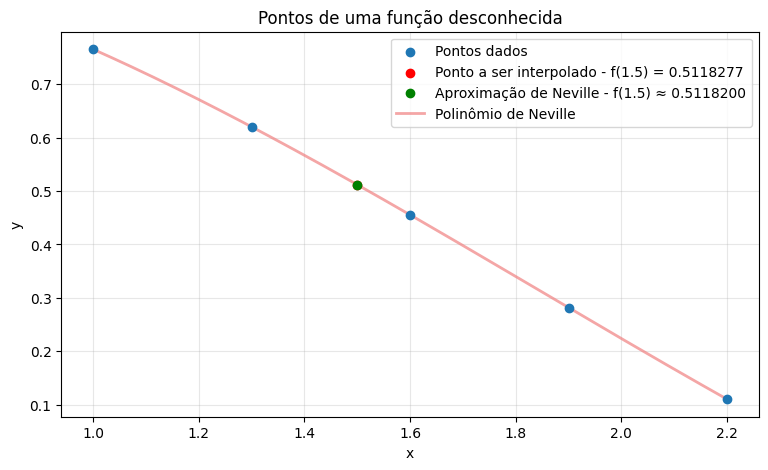

In [9]:
# Inicialização dos pontos
x_i = df['x'].values
y_i = df['f(x)'].values

# Valor real
x = 1.5
y = 0.5118277

# Implementação da interpolação de Neville
def neville_interpolation(x, x_values, f_values, epsilon):
    
    n = len(x_values)
    Q = np.zeros((n, n))
    
    for i in range(n):
        Q[i, 0] = f_values[i]
    
    for i in range(1, n):
        for j in range(1, i + 1):
            num = ((x - x_values[i - j]) * Q[i, j - 1] - (x - x_values[i]) * Q[i - 1, j - 1]) 
            dem = (x_values[i] - x_values[i - j])
            Q[i, j] = num / dem
        if abs(Q[i][i] - Q[i-1][i-1]) < epsilon:
            return Q[i][i], Q # Retorna o valor e a tabela
    
    return Q[n-1][n-1], Q

# Cálculo do valor aproximado
x_curva = np.linspace(x_i.min(), x_i.max(), 200)
y_curva = [neville_interpolation(val, x_i, y_i, 1e-5)[0] for val in x_curva]

# Cálculo do valor aproximado
y_n, _ = neville_interpolation(x, x_i, y_i, 1e-5)

plt.figure(figsize=(9,5))
plt.scatter(x_i, y_i, label="Pontos dados", zorder=10)
plt.scatter(x, y, color='red', label="Ponto a ser interpolado - f(1.5) = 0.5118277", zorder=10)
plt.scatter(x, y_n, color='green', label="Aproximação de Neville - f(1.5) ≈ {:.7f}".format(y_n), zorder=10)
plt.plot(x_curva, y_curva, color='lightcoral', label='Polinômio de Neville', linewidth=2, alpha=0.7, zorder=5)
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Pontos de uma função desconhecida")
plt.legend()
plt.show()

__Exercício 4__. Use o método de Neville, implementado anteriormente, para aproximar $\sqrt{3}$ com as seguintes funções e valores.

a. $f(x) = 3^x$ e os valores $x_0 = −2, x_1 = −1, x_2 = 0, x_3 = 1 \,\,\text{e}\,\, x_4 = 2.$

b. $f(x) = \sqrt{x}$ e os valores $x_0 = 0, x_1 = 1, x_2 = 2, x_3 = 4 \,\,\text{e}\,\, x_4 = 5$.

c. Compare a precisão da aproximação de (a) e (b). 

In [10]:
import math

y_real = math.sqrt(3)

a.

In [11]:
# Inicialização dos pontos
x = [-2, -1, 0,1,2]
y = [3**(-2), 3**(-1), 3**(0), 3**(1), 3**(2)]
x_alvo = 0.5

# Cálculo do valor aproximado
y_alvoa, Q = neville_interpolation(x_alvo, x, y, epsilon=1e-7)

# Cálculo do erro absoluto
erro_abs = abs(y_real - y_alvoa)

print(f"{'Descrição':<50} | {'Valor':<15} | {'Erro Absoluto':<15}")
print("-" * 86)
print(f"{'Aproximação (Neville)':<50} | {y_alvoa:<15.7f} | {'-':<15}")
print(f"{'Valor Real f(0.5)':<50} | {y_real:<15.7f} | {'-':<15}")
print(f"{'Resultado do Erro':<50} | {'-':<15} | {erro_abs:<15.7e}")

Descrição                                          | Valor           | Erro Absoluto  
--------------------------------------------------------------------------------------
Aproximação (Neville)                              | 1.7083333       | -              
Valor Real f(0.5)                                  | 1.7320508       | -              
Resultado do Erro                                  | -               | 2.3717474e-02  


b.

In [12]:
import math

# Inicialização dos pontos
x = [0, 1, 2, 4, 5]
y = [math.sqrt(0), math.sqrt(1), math.sqrt(2), math.sqrt(4), math.sqrt(5)]

# Cálculo do valor aproximado
x_alvo = 3
y_alvob, Q = neville_interpolation(x_alvo, x, y, epsilon=1e-7)

print(f"{'Descrição':<55} | {'Valor':<15}")
print("-" * 73)
print(f"{'Valor aproximado usando Neville\'s Iterated Interpolation':<55} | {y_alvob:<15.7f}")
print(f"{'Valor real de f(3)':<55} | {y_real:<15.7f}")
print(f"{'Erro absoluto':<55} | {abs(y_real - y_alvob):<15.7f}")

Descrição                                               | Valor          
-------------------------------------------------------------------------
Valor aproximado usando Neville's Iterated Interpolation | 1.6906068      
Valor real de f(3)                                      | 1.7320508      
Erro absoluto                                           | 0.0414440      


c.

Os dois métodos geraram aproximações que não atingiram o erro definido de 1e-5 com a proposta apresentada em a tendo o melhor resultado com um erro absoluto de 0.0237175. Esses resultados podem ser aprimorados ao escolher pontos mais próximos do x alvo, como visto abaixo onde os dois métodos conseguiram encontrar aproximações melhores. 

In [13]:
# Inicialização dos pontos
x = [-1, -0.5, 0, 1, 1.5]
y = [3**(-1), 3**(-0.5), 3**(0), 3**(1), 3**(1.5)]

# Cálculo do valor aproximado
x_alvo = 0.5
y_alvo, Q = neville_interpolation(x_alvo, x, y, epsilon=1e-5)


print(f"Valor aproximado usando Neville's Iterated Interpolation: {y_alvo:.5f}")
print(f"Valor real de f(0.5): {y_real:.5f}")
print(f"Erro absoluto: {abs(y_real - y_alvo):.5f}")

Valor aproximado usando Neville's Iterated Interpolation: 1.72504
Valor real de f(0.5): 1.73205
Erro absoluto: 0.00701


In [14]:
import math

# Inicialização dos pontos
x = [1.5, 2, 2.5, 3.5, 4]
y = [math.sqrt(1.5), math.sqrt(2), math.sqrt(2.5), math.sqrt(3.5), math.sqrt(4)]

# Cálculo do valor aproximado
x_alvo = 3
y_alvo, Q = neville_interpolation(x_alvo, x, y, epsilon=1e-5)

print(f"Valor aproximado usando Neville's Iterated Interpolation: {y_alvo:.5f}")
print(f"Valor real de f(3): {y_real:.7f}")
print(f"Erro absoluto: {abs(y_real - y_alvo):.5f}")

Valor aproximado usando Neville's Iterated Interpolation: 1.73192
Valor real de f(3): 1.7320508
Erro absoluto: 0.00013


__Exercício 5__. Construa uma sequência de valores de interpolação $y_n$ para $f(1+\sqrt{10})$, onde $f(x)=(1+x^2)^{-1}$ para $-5 \leq x \leq 5$, da seguinte forma: Para cada $n=1,2,\dots, 10$, seja $h=10/n$ y $y_n=P_n(1+\sqrt{10})$, onde $P_n(x)$ é o polinômio interpolador de $f(x)$ nos pontos $x_0^{(n)}, x_1^{(n)}, \dots, x_n^{(n)}$ e $x_j^{(n)}= -5 + jh$, para cada $j=0,1,2,\dots, n$. A sequência ${y_n}$ parece convergir para $f(1 + \sqrt{10})$?  

In [15]:
import math

# Inicialização dos pontos
x_alvo = 1 + math.sqrt(10)
y_real = (1 + (x_alvo ** 2)) ** -1

# Cálculo do valor aproximado
for n in range(1, 11):
    h = 10 / n
    x = []
    y = []
    for j in range(0, n + 1):
        xi = -5 + j * h
        x.append(xi)
        yi = (1 + (x[-1] ** 2)) ** -1
        y.append(yi)
    y_alvo, Q = neville_interpolation(x_alvo, x, y, epsilon=1e-5)
    print(f"{'Descrição':<45} | {'Valor':<15}")
    print("-" * 63)

    # Linhas de dados formatadas
    print(f"{f'Grau do polinômio (n)':<45} | {n:<15}")
    print(f"{'Aproximação (Neville)':<45} | {y_alvo:<15.5f}")
    print(f"{'Valor Real':<45} | {y_real:<15.5f}")
    print(f"{'Erro Absoluto':<45} | {erro_abs:<15.5f}")

Descrição                                     | Valor          
---------------------------------------------------------------
Grau do polinômio (n)                         | 1              
Aproximação (Neville)                         | 0.03846        
Valor Real                                    | 0.05457        
Erro Absoluto                                 | 0.02372        
Descrição                                     | Valor          
---------------------------------------------------------------
Grau do polinômio (n)                         | 2              
Aproximação (Neville)                         | 0.33367        
Valor Real                                    | 0.05457        
Erro Absoluto                                 | 0.02372        
Descrição                                     | Valor          
---------------------------------------------------------------
Grau do polinômio (n)                         | 3              
Aproximação (Neville)                   

Apesar de estarmos trabalhando com um número cada vez maior de pontos, a sequência não está convergindo para o valor real de $f(1 + \sqrt{10})$. Isso demonstra que escolher pontos igualmente espaçados pode acabar prejudicando a interpolação. Para lidar com este problema, existem técnicas específicas para selecionar pontos como os pontos de chebyshev. Para demonstrar a diferença de performance, vamos aplicar esta técnica no exemplo utilizado neste exercício no código abaixo.

In [16]:
import math

# Inicialização dos pontos
x_alvo = 1 + math.sqrt(10)
y_real = (1 + (x_alvo ** 2)) ** -1

# Cálculo do valor aproximado usando pontos de Chebyshev
for n in range(1, 11):
    h = 10 / n
    x = []
    y = []
    for j in range(0, n + 1):
        xi = (math.cos((2 * j + 1) * math.pi / (2 * n + 2))) * 5
        x.append(xi)
        yi = (1 + (x[-1] ** 2)) ** -1
        y.append(yi)
    y_alvo, Q = neville_interpolation(x_alvo, x, y, epsilon=1e-5)
    print(f"{'Descrição':<50} | {'Valor':<15}")
    print("-" * 68)
    print(f"{f'Grau do polinômio (n)':<50} | {n:<15}")
    print(f"{'Valor aproximado (Neville)':<50} | {y_alvo:<15.5f}")
    print(f"{'Valor real':<50} | {y_real:<15.5f}")
    print(f"{'Erro absoluto':<50} | {abs(y_real - y_alvo):<15.5f}")

Descrição                                          | Valor          
--------------------------------------------------------------------
Grau do polinômio (n)                              | 1              
Valor aproximado (Neville)                         | 0.07407        
Valor real                                         | 0.05457        
Erro absoluto                                      | 0.01950        
Descrição                                          | Valor          
--------------------------------------------------------------------
Grau do polinômio (n)                              | 2              
Valor aproximado (Neville)                         | 0.12281        
Valor real                                         | 0.05457        
Erro absoluto                                      | 0.06824        
Descrição                                          | Valor          
--------------------------------------------------------------------
Grau do polinômio (n)             

__Exercício 6__.  Veja o psudocódigo a seguir e compare com a implementação apresentada em sala de aula . Construa uma função que implemente o método de Diferenças Divididas para interpolação por polinômios de Lagrange. Utilize como exemplo os valores fornecidos no arqivo Table-3_2.csv para estimar o valor de $x=1{,}5$. A função que se deseja aproximar é, na verdade, a função de _Bessel_ de primeira espécie de ordem zero, cujo valor em $1{,}5$ é conhecido como $0{,}5118277$.  

In [17]:
"""
Newton’s Divided-Difference Formula
To obtain the divided-difference coefficients of the interpolatory polynomial P on the (n+1)
distinct numbers x0 , x1 , . . . , xn for the function f:
INPUT numbers x0 , x1 , . . . , xn ; values f (x0 ), f (x1 ), . . . , f (xn ) as 
F0,0 , F1,0 , . . . , Fn,0 .
OUTPUT the numbers F0,0 , F1,1 , . . . , Fn,n as the divided-difference coefficients of P.
Step 1. for j = 1 to n do
            for i = j to n do
                Fi,j = (xi - xi-j)Fi,j-1 - (xi - xi-j)Fi-1,j-1 /(xi - xi-j)
Step 2. return F0,0 , F1,1 , . . . , Fn,n
"""

'\nNewton’s Divided-Difference Formula\nTo obtain the divided-difference coefficients of the interpolatory polynomial P on the (n+1)\ndistinct numbers x0 , x1 , . . . , xn for the function f:\nINPUT numbers x0 , x1 , . . . , xn ; values f (x0 ), f (x1 ), . . . , f (xn ) as \nF0,0 , F1,0 , . . . , Fn,0 .\nOUTPUT the numbers F0,0 , F1,1 , . . . , Fn,n as the divided-difference coefficients of P.\nStep 1. for j = 1 to n do\n            for i = j to n do\n                Fi,j = (xi - xi-j)Fi,j-1 - (xi - xi-j)Fi-1,j-1 /(xi - xi-j)\nStep 2. return F0,0 , F1,1 , . . . , Fn,n\n'

In [18]:
# Implementação da fórmula de Newton para diferenças divididas
def divided_differences(xs, ys):
    n = len(xs)
    table = np.zeros((n, n), dtype=float)
    table[:, 0] = ys

    for j in range(1, n):
        for i in range(n - j):
            table[i, j] = (table[i + 1, j - 1] - table[i, j - 1]) / (xs[i + j] - xs[i])

    return table

O pseudocódigo apresentado realiza o calculo dos coeficientes usados para calcular a interpolação de newton, assim como o código apresentado durante a aula. A maior diferença entre as duas implementações é que a implementação mostrada em aula devolve a matriz completa enquanto o pseudocódigo devolve somente a diagonal principal gerada pelo código.

In [19]:
# Implementação da interpolação de Newton
def dif_newton(x, xs, ys):
    coef = np.zeros((len(xs), len(xs)))
    coef[:, 0] = ys
    n = len(xs)
    for j in range(1, n):
        for i in range(n - 1, j - 1, -1):
            coef[i, j] = (coef[i, j-1] - coef[i-1, j-1]) / (xs[i] - xs[i-j])
    result = coef[n-1, n-1]
    for k in range(n - 2, -1, -1):
        result = coef[k, k] + (x - xs[k]) * result
    return result

In [20]:
# Exemplo 1. Importar a tabela como um dataframe do arquivo Table-3_2.csv
df = pd.read_csv('Table-3_2.csv')

# Incialização dos pontos
x_i = df['x'].values
y_i = df['f(x)'].values

# Valor real
x = 1.5
y = 0.5118277

# Cálculo do valor aproximado
y_alvo = dif_newton(x, x_i, y_i)


print(f"Valor aproximado usando Newton's Divided-Difference Interpolation: {y_alvo:.7f}")
print(f"Valor real de f(1.5): {y}")
print(f"Erro absoluto: {abs(y - y_alvo):.7f}")


Valor aproximado usando Newton's Divided-Difference Interpolation: 0.5118200
Valor real de f(1.5): 0.5118277
Erro absoluto: 0.0000077


__Exrcício 7__. Utilize a fórmula de diferenças de Newton para construir polinômios interpoladores de grau um, dois e três para os dados a seguir. Aproxime o valor especificado utilizando cada um dos polinômios.

a. $f(0{,}43) \,\, \text{se}\,\, f(0)=1, f(0{,}25)=1{,}64872, f(0{,}5)=2{,}71828, f(0{,}75)=4.48169$

b. $f(0{,}25) \,\, \text{se}\,\, f(−1)=0{,}86199480, f(−0{,}5)=0{,}95802009, f(0)=1{,}0986123, f(0{,}5)=
1{,}2943767$

In [21]:
# Inicialização dos pontos
x = [0, 0.25, 0.5, 0.75]
y = [1, 1.64872, 2.71828, 4.48169]
x_alvo = 0.43

# Cálculo do valor aproximado
for i in range(1, len(x)):
    y_alvo = dif_newton(x_alvo, x[:i+1], y[:i+1])
    print(f"Valor aproximado com o polinômio de {i} grau: {y_alvo:.5f}")

Valor aproximado com o polinômio de 1 grau: 2.11580
Valor aproximado com o polinômio de 2 grau: 2.37638
Valor aproximado com o polinômio de 3 grau: 2.36060


In [22]:
# Inicialização dos pontos
x = [-1, -0.5, 0, 0.5]
y = [0.86199480, 0.95802009, 1.0986123, 1.2943767]
x_alvo = 0.25

# Cálculo do valor aproximado
for i in range(1, len(x)):
    y_alvo = dif_newton(x_alvo, x[:i+1], y[:i+1])
    print(f"Valor aproximado com o polinômio de {i} grau: {y_alvo:.5f}")

Valor aproximado com o polinômio de 1 grau: 1.10206
Valor aproximado com o polinômio de 2 grau: 1.18562
Valor aproximado com o polinômio de 3 grau: 1.18894


__Exercício 8__. Um censo da população dos Estados Unidos é realizado a cada 10 anos. A tabela a seguir lista a população, em milhares de pessoas, de 1950 a 2000. Os dados também estão representados na figura.

In [23]:
# Importar a tabela como um dataframe do arquivo population.csv
df = pd.read_csv('population.csv')
display(df)

,Year,Population
0,1950,151326
1,1960,179323
2,1970,203302
3,1980,226542
4,1990,249633
5,2000,281422


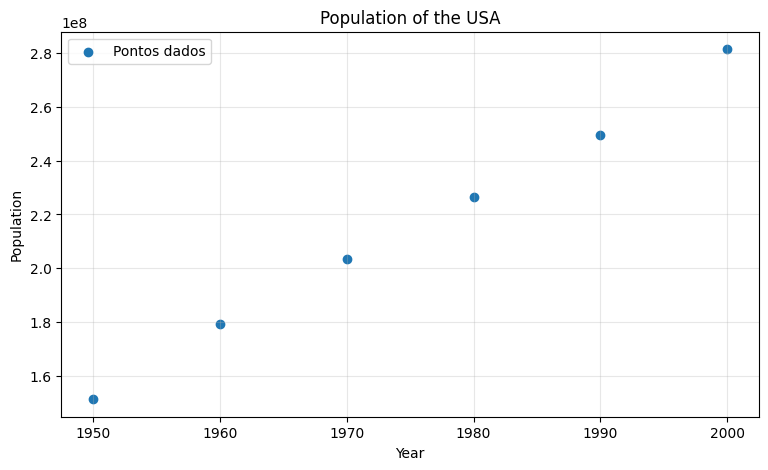

In [24]:
# Visualização dos dados
xs = df['Year'].values
ys = df['Population'].values*1000


plt.figure(figsize=(9,5))
plt.scatter(xs, ys, label="Pontos dados")
plt.grid(True, alpha=0.3)
plt.xlabel("Year")
plt.ylabel("Population")
plt.title("Population of the USA")
plt.legend()
plt.show()

a. Use diferenças divididas para aproximar a população nos anos de 1940, 1975 e 2020.

b. A ​​população em 1940 era de aproximadamente 132.165.000. Quão precisos você acha que são seus números para 1975 e 2020?

In [25]:
# Inicialização dos pontos
df = pd.read_csv('population.csv')
ano = df['Year'].values
pop = df['Population'].values

# Calculo do valor aproximado
y1 = dif_newton(1940, ano, pop)
y2 = dif_newton(1975, ano, pop)
y3 = dif_newton(2020, ano, pop)


print(f"Valor aproximado usando interpolação de Newton para 1940: {y1:.0f}")
print(f"Valor aproximado usando interpolação de Newton para 1975: {y2:.0f}")
print(f"Valor aproximado usando interpolação de Newton para 2020: {y3:.0f}")


Valor aproximado usando interpolação de Newton para 1940: 102397
Valor aproximado usando interpolação de Newton para 1975: 215043
Valor aproximado usando interpolação de Newton para 2020: 513443


In [26]:
# Valor real da população em 1940
y_real = 132165

print(f"Valor real da população em 1940: {y_real}")
print(f"Valor aproximado usando interpolação de Newton para 1940: {y1:.0f}")
print(f"Erro absoluto para 1940: {abs(y_real - y1):5f}")


Valor real da população em 1940: 132165
Valor aproximado usando interpolação de Newton para 1940: 102397
Erro absoluto para 1940: 29768.000000


Como visto no exemplo acima, esta interpolação conseguiu gerar uma aproximação imprecisa da população real. Por conta dessa diferença, é possível supor que os valorer obtidos com as outras aproximações realizadas também são imprecisos.